In [ ]:
!pip install scikit-learn pandas numpy joblib matplotlib -q

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import joblib
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)
print("Библиотеки загружены")

Библиотеки загружены


In [2]:
# Генерируем синтетический датасет (если файла ещё нет)
DATA_PATH = Path("Downloads/smart_home_sensors.csv")
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    N = 2000
    timestamps = pd.date_range("2026-01-01", periods=N, freq="5min")
    hour = (timestamps.hour + timestamps.minute / 60.0).to_numpy(dtype=float)

    temperature = 21 + 2 * np.sin(2 * np.pi * hour / 24) + RNG.normal(0, 0.4, N)
    humidity = 45 + 8 * np.sin(2 * np.pi * (hour - 6) / 24) + RNG.normal(0, 2, N)
    motion = (RNG.random(N) < 0.12).astype(float)
    lux = np.clip(300 * np.sin(np.pi * hour / 24) ** 2 + RNG.normal(0, 30, N), 0, 800)

    # Аномалии ~5%
    n_anom = int(0.05 * N)
    anom_idx = RNG.choice(N, size=n_anom, replace=False)
    for i, idx in enumerate(anom_idx):
        kind = i % 4
        if kind == 0:
            temperature[idx] += RNG.choice([-8, 10])
        elif kind == 1:
            humidity[idx] = RNG.uniform(85, 98)
        elif kind == 2 and 1 <= hour[idx] <= 4:
            motion[idx] = 1.0
            lux[idx] = RNG.uniform(0, 15)
        else:
            lux[idx] = RNG.uniform(900, 1200)

    df = pd.DataFrame({
        "timestamp": timestamps,
        "temperature": np.round(temperature, 2),
        "humidity": np.round(humidity, 1),
        "motion": motion.astype(int),
        "lux": np.round(lux, 1),
        "is_anomaly": 0,
    })
    df.loc[anom_idx, "is_anomaly"] = 1
    df.to_csv(DATA_PATH, index=False)
    print(f"Создан датасет: {DATA_PATH} ({len(df)} строк)")
else:
    df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
    print(f"Загружен датасет: {DATA_PATH} ({len(df)} строк)")

df["hour"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60.0
df.head()

Создан датасет: Downloads/smart_home_sensors.csv (2000 строк)


,timestamp,temperature,humidity,motion,lux,is_anomaly,hour
0,2026-01-01 00:00:00,21.12,36.1,0,20.9,0,0.000000
1,2026-01-01 00:05:00,20.63,35.7,0,0.0,0,0.083333
2,2026-01-01 00:10:00,21.39,37.9,0,12.9,0,0.166667
3,2026-01-01 00:15:00,21.51,37.5,0,0.0,0,0.250000
4,2026-01-01 00:20:00,20.39,34.2,0,4.5,0,0.333333


Распределение аномалий:
is_anomaly
0    1900
1     100
Name: count, dtype: int64

Статистики признаков:


,temperature,humidity,motion,lux
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,20.997845,45.673600,0.123000,172.214100
std,1.784345,7.853822,0.328519,173.485536
min,11.120000,31.200000,0.000000,0.000000
25%,19.660000,39.800000,0.000000,48.175000
50%,20.985000,45.300000,0.000000,155.600000
75%,22.330000,50.500000,0.000000,252.625000
max,33.220000,97.300000,1.000000,1192.400000


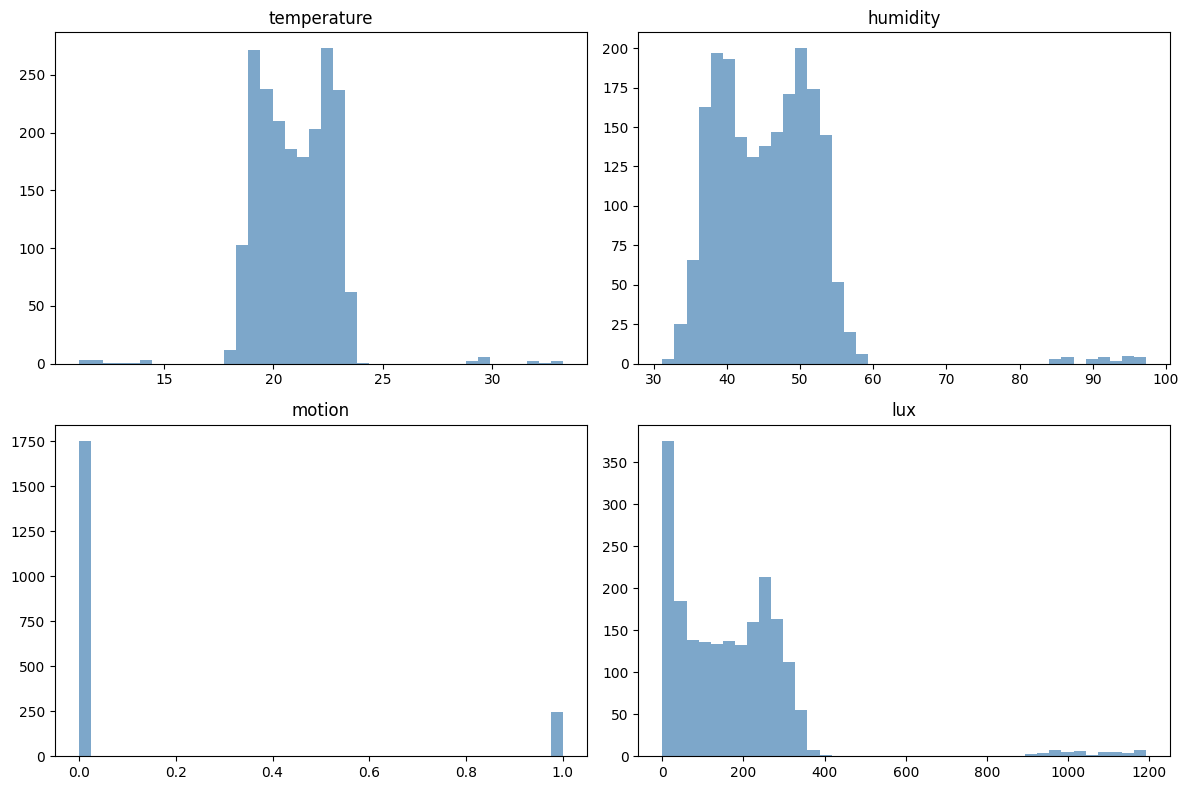

In [3]:
print("Распределение аномалий:")
print(df["is_anomaly"].value_counts())
print("\nСтатистики признаков:")
display(df[["temperature", "humidity", "motion", "lux"]].describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["temperature", "humidity", "motion", "lux"]):
    ax.hist(df[col], bins=40, alpha=0.7, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [4]:
FEATURES = ["temperature", "humidity", "motion", "lux", "hour"]
X = df[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples="auto",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_scaled)

scores = model.decision_function(X_scaled)   # чем меньше — тем аномальнее
preds = (model.predict(X_scaled) == -1).astype(int)

df["pred_anomaly"] = preds
df["anomaly_score"] = scores
print("Модель обучена")


Модель обучена


In [5]:
y_true = df["is_anomaly"].values
y_pred = df["pred_anomaly"].values

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print()
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"], zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

Precision: 0.740
Recall:    0.740
F1-score:  0.740

              precision    recall  f1-score   support

      normal       0.99      0.99      0.99      1900
     anomaly       0.74      0.74      0.74       100

    accuracy                           0.97      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.97      0.97      0.97      2000

Confusion matrix:
[[1874   26]
 [  26   74]]


In [6]:
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_DIR / "isolation_forest.joblib")
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
df.to_csv(REPORT_DIR / "predictions.csv", index=False)

print("Сохранено:")
print(f"  - {MODEL_DIR / 'isolation_forest.joblib'}")
print(f"  - {MODEL_DIR / 'scaler.joblib'}")
print(f"  - {REPORT_DIR / 'predictions.csv'}")


Сохранено:
  - ../models/isolation_forest.joblib
  - ../models/scaler.joblib
  - ../reports/predictions.csv
